# Chapter 3: Labeling

**AFML Ch. 3** -- Triple-barrier method and trend scanning labels.

Traditional labeling (e.g., sign of next-day return) ignores path dependency and risk.
The triple-barrier method defines profit-taking, stop-loss, and maximum holding period
boundaries around each trade entry point, producing labels that reflect actual trading
outcomes. Trend scanning provides a model-free way to detect local trends.

**Topics covered:**

- Daily volatility estimation (EWMA)
- CUSUM event filter for entry point detection
- **Triple-barrier labeling** (`get_events`, `get_bins`)
- **Trend scanning** labels
- **Meta-labeling** and bet sizing
- Polars expression API for labeling

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pymlfinance
from pymlfinance import TickData, TripleBarrierConfig

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

## Generate Synthetic Price Series

We create a 1,000-day price series with both trending and mean-reverting components.
This mixture produces realistic-looking paths with local trends that the labeling
methods can detect.

In [2]:
np.random.seed(42)

n = 1000
# Mean-reverting + trending components
trend = np.linspace(0, 2, n)
noise = np.cumsum(np.random.randn(n) * 0.5)
mean_reversion = -0.05 * noise
prices = 100.0 * np.exp((trend + noise + np.cumsum(mean_reversion)) * 0.01)
timestamps = np.arange(n, dtype=np.float64) * 86400.0  # daily timestamps

print(f"Generated {n} daily prices, range: {prices.min():.2f} - {prices.max():.2f}")

Generated 1000 daily prices, range: 97.19 - 208.02


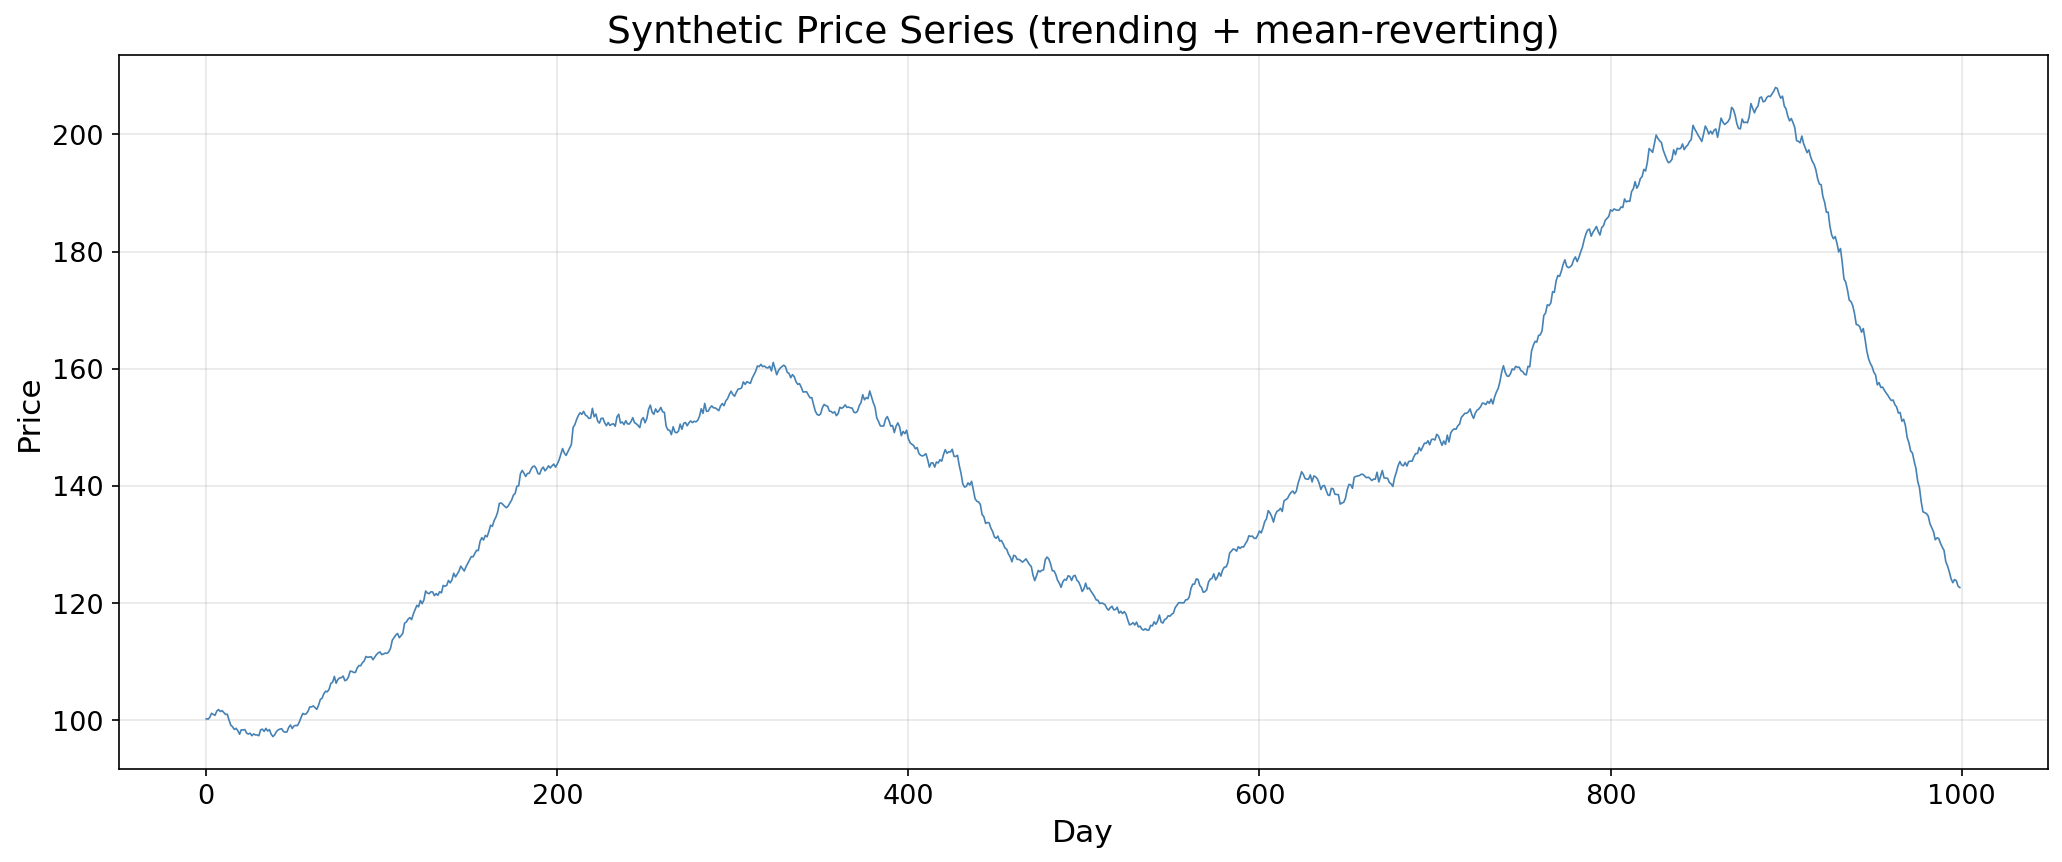

In [3]:
# Plot the synthetic price series
fig, ax = plt.subplots()
ax.plot(prices, color='steelblue', linewidth=0.8)
ax.set_xlabel('Day')
ax.set_ylabel('Price')
ax.set_title('Synthetic Price Series (trending + mean-reverting)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Daily Volatility (EWMA)

Daily volatility is estimated using an exponentially weighted moving average (EWMA)
of absolute returns. This adaptive estimate is used to scale the triple-barrier
widths relative to current market conditions.

In [4]:
daily_vol = pymlfinance.labeling.daily_volatility(prices, timestamps.tolist(), span=50)
print(f"--- Daily Volatility (EWMA span=50) ---")
print(f"  Mean vol: {np.nanmean(daily_vol):.6f}")
print(f"  Min vol:  {np.nanmin(daily_vol):.6f}")
print(f"  Max vol:  {np.nanmax(daily_vol):.6f}")

--- Daily Volatility (EWMA span=50) ---
  Mean vol: 0.006626
  Min vol:  0.000000
  Max vol:  0.009068


## CUSUM Event Filter

The CUSUM filter identifies structural breaks in the return series. These are used as
candidate entry points for the triple-barrier method. Only significant price moves
trigger events, filtering out noise.

In [ ]:
# CUSUM filter applied to close prices (AFML Snippet 2.5)
# Detects structural breaks when cumulative price moves exceed the threshold.
threshold = np.nanmean(daily_vol[1:]) * prices.mean() * 1.5
entry_indices = pymlfinance.data.cusum_filter(prices, threshold)
print(f"--- CUSUM Event Filter ---")
print(f"  Threshold: {threshold:.4f} (1.5x mean vol x mean price)")
print(f"  Entry events: {len(entry_indices)}")

## Triple-Barrier Labeling

The triple-barrier method places three barriers around each entry point:

1. **Upper barrier** (profit-take): price rises by `upper_barrier` x daily vol
2. **Lower barrier** (stop-loss): price falls by `lower_barrier` x daily vol
3. **Vertical barrier** (max holding period): time expires after `max_holding_period` bars

The label is determined by which barrier is touched first:
- `+1` = profit-take hit first
- `-1` = stop-loss hit first
- `0` = vertical barrier (time expired)

In [6]:
config = TripleBarrierConfig(
    upper_barrier=2.0,   # 2x daily vol
    lower_barrier=2.0,   # 2x daily vol
    max_holding_period=20  # 20 bars max hold
)
events = pymlfinance.labeling.get_events(prices, entry_indices, config, daily_vol)
labels = pymlfinance.labeling.get_bins(events)
print(f"--- Triple-Barrier Labels ---")
print(f"  Total events: {len(events)}")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    label_name = {-1: "Stop-loss", 0: "Vertical", 1: "Profit-take"}
    print(f"  {label_name.get(int(u), str(u)):>12s} ({int(u):+d}): {c}")
if events:
    print(f"  First event: entry={events[0].entry_idx}, exit={events[0].exit_idx}, "
          f"type={events[0].touch_type}, ret={events[0].return_value:.4f}")

--- Triple-Barrier Labels ---
  Total events: 230
     Stop-loss (-1): 98
   Profit-take (+1): 132
  First event: entry=7, exit=11, type=lower, ret=-0.0082


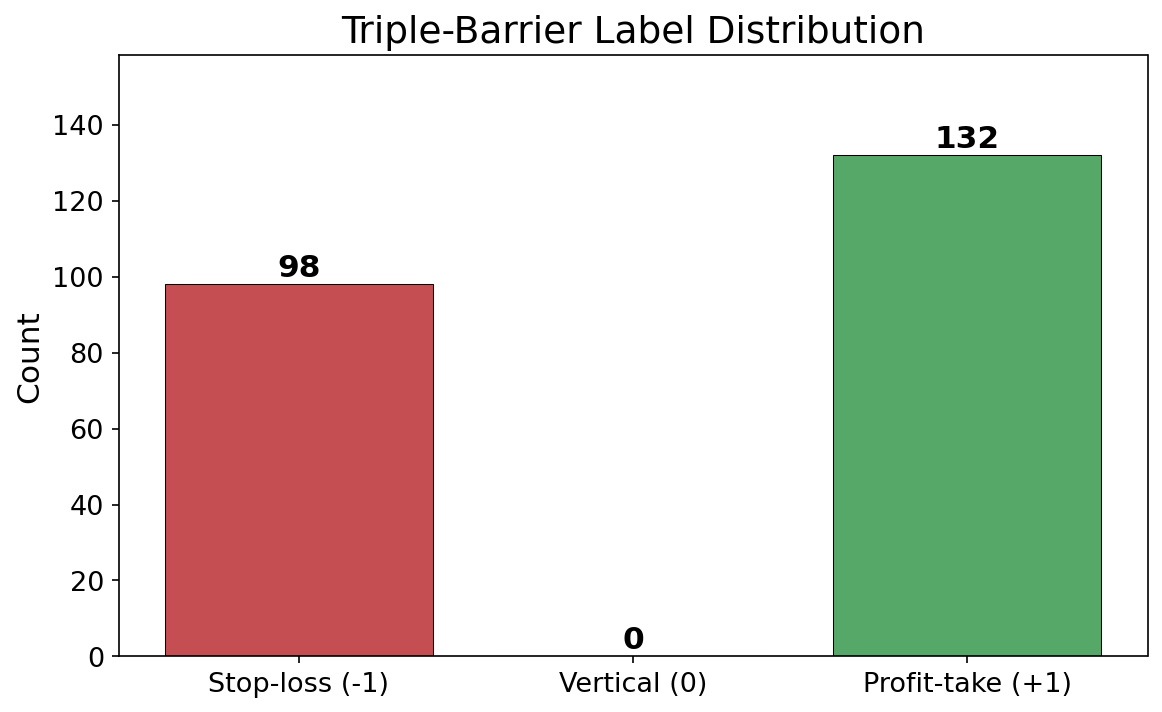

In [7]:
# Label distribution histogram
fig, ax = plt.subplots(figsize=(8, 5))
label_names = ['Stop-loss (-1)', 'Vertical (0)', 'Profit-take (+1)']
label_colors = ['#C44E52', '#8C8C8C', '#55A868']
count_map = dict(zip(unique, counts))
bar_counts = [count_map.get(-1, 0), count_map.get(0, 0), count_map.get(1, 0)]

bars = ax.bar(label_names, bar_counts, color=label_colors, edgecolor='black', linewidth=0.5)
for bar, count in zip(bars, bar_counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=15)
ax.set_ylabel('Count')
ax.set_title('Triple-Barrier Label Distribution')
ax.set_ylim(0, max(bar_counts) * 1.2)
plt.tight_layout()
plt.show()

In [ ]:
# Price plot with triple-barrier entry/exit markers
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(prices, color='steelblue', linewidth=0.6, alpha=0.7, label='Price')

for evt in events:
    entry = evt.entry_idx
    exit_idx = evt.exit_idx
    if evt.touch_type == "upper":  # profit-take
        color = '#55A868'
    elif evt.touch_type == "lower":  # stop-loss
        color = '#C44E52'
    else:  # vertical
        color = '#8C8C8C'
    ax.plot([entry, exit_idx], [prices[entry], prices[exit_idx]],
            color=color, alpha=0.4, linewidth=1)

# Entry points
entry_idxs = [e.entry_idx for e in events]
ax.scatter(entry_idxs, prices[entry_idxs], color='blue', s=20, zorder=5,
           marker='^', label='Entry')

# Exit points colored by label
for label_val, color, name in [("lower", '#C44E52', 'Stop-loss'),
                                ("vertical", '#8C8C8C', 'Vertical'),
                                ("upper", '#55A868', 'Profit-take')]:
    exit_idxs = [e.exit_idx for e in events if e.touch_type == label_val]
    if exit_idxs:
        ax.scatter(exit_idxs, prices[exit_idxs], color=color, s=20, zorder=5,
                   marker='v', label=f'Exit: {name}')

ax.set_xlabel('Day')
ax.set_ylabel('Price')
ax.set_title('Triple-Barrier Events: Entry and Exit Points')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Trend Scanning Labels

Trend scanning is a model-free approach to labeling. For each observation, it fits
linear regressions over multiple forward windows and selects the one with the highest
t-statistic. The sign of the best-fit slope determines the label (+1 or -1).

In [9]:
trend_labels = pymlfinance.labeling.trend_scanning_label_series(prices, max_window=20)
print(f"--- Trend Scanning Labels (max_window=20) ---")
print(f"  Labels computed: {len(trend_labels)}")
t_unique, t_counts = np.unique(trend_labels, return_counts=True)
for u, c in zip(t_unique, t_counts):
    print(f"  Label {int(u):+d}: {c}")

--- Trend Scanning Labels (max_window=20) ---
  Labels computed: 998
  Label -1: 394
  Label +1: 604


## Meta-Labeling

Meta-labeling takes the output of a primary model (which predicts direction) and
learns *when* to trade. The meta-labeler outputs 1 (trade) or 0 (no trade), effectively
learning to filter false positives from the primary model.

In [10]:
meta_labeler = pymlfinance.labeling.MetaLabeler(min_probability=0.5)
# Simulate primary model predictions (random +-1)
primary_preds = [1 if np.random.random() > 0.5 else -1 for _ in range(len(events))]
meta_labels = meta_labeler.generate_labels(events, primary_preds)
print(f"--- Meta-Labeling ---")
print(f"  Meta-labels: {len(meta_labels)}")
print(f"  Trade signals: {np.sum(meta_labels == 1)}")
print(f"  No-trade signals: {np.sum(meta_labels == 0)}")

# Test bet sizing
bet = meta_labeler.bet_size(0.7)
print(f"  Bet size for p=0.7: {bet:.4f}")

--- Meta-Labeling ---
  Meta-labels: 230
  Trade signals: 129
  No-trade signals: 101
  Bet size for p=0.7: 0.4000


## Polars Expression API

The `.ml` namespace on Polars expressions provides the same labeling functions
in a DataFrame-native API. This is convenient for pipeline-style data processing.

In [11]:
import pymlfinance.polars  # registers .ml namespace

df = pl.DataFrame({"price": prices})
vol_df = df.with_columns(
    pl.col("price").ml.daily_volatility(span=50).alias("daily_vol"),
)
print(f"  Daily vol DataFrame shape: {vol_df.shape}")
print(vol_df.head(5))

  Daily vol DataFrame shape: (1000, 2)
shape: (5, 2)
┌────────────┬───────────┐
│ price      ┆ daily_vol │
│ ---        ┆ ---       │
│ f64        ┆ f64       │
╞════════════╪═══════════╡
│ 100.236218 ┆ 0.0       │
│ 100.159976 ┆ 0.0       │
│ 100.461603 ┆ 0.000746  │
│ 101.167592 ┆ 0.001078  │
│ 100.993279 ┆ 0.002025  │
└────────────┴───────────┘


In [12]:
# trend_scanning returns fewer rows than input, so select separately
trend_result = df.select(
    pl.col("price").ml.trend_scanning_label_series(max_window=20).alias("trend_label"),
)
print(f"  Trend labels shape: {trend_result.shape}")
print(trend_result.head(5))

  Trend labels shape: (998, 1)
shape: (5, 1)
┌─────────────┐
│ trend_label │
│ ---         │
│ i32         │
╞═════════════╡
│ 1           │
│ -1          │
│ -1          │
│ -1          │
│ -1          │
└─────────────┘


## Exercises

1. **Barrier width sensitivity**: Vary the triple-barrier widths (1x, 2x, 3x vol) and compare label distributions. Wider barriers should produce fewer stop-loss events.

2. **Asymmetric barriers**: Use asymmetric barriers (wider upper, tighter lower) for trend-following strategies. How does this shift the label distribution?

3. **Trend scanning windows**: Compare trend scanning with different `max_window` values (10, 20, 50). Larger windows detect longer-duration trends.